## Avoiding rivers during the rainy season

The following code develops a routing function that helps avoid flooding events when routing withinn the Amazon rainforest. It considers river location, seasonality, and road networks.

At first, we develop the routing pipeline without integrating river info, and then weight to avoid rivers.

In [1]:
# load in necessary libraries
import os
import pandas as pd
import geopandas as gpd
from pyprojroot import here
import matplotlib.pyplot as plt
import networkx as nx
from math import radians, sin, cos, sqrt, atan2
from scipy.spatial import KDTree

In [2]:
# read in data
osm_roads = gpd.read_file(here("challenge-docs/challenge-3/roads-osm-paragominas.geojson")) # OSM roads
previsia_roads = gpd.read_file(here("challenge-docs/challenge-3/roads-previsia-2025-paragominas.geojson")) # remotely-sensed roads
rivers = gpd.read_file(here("my-data/para/PA_1505502_RIOS_SIMPLES.shp")).set_crs("EPSG:31983").to_crs(osm_roads.crs) # river network
test = pd.read_csv(here("challenge-docs/challenge-3/test-pairs.csv")) # test pairs provided by hackathon

In [3]:
# same crs?
assert osm_roads.crs == previsia_roads.crs
assert rivers.crs == osm_roads.crs
osm_roads.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [4]:
# save test pairs as geo
test_pairs = test.assign( # iterate across appropriate columns and create points
    origin=list(zip(test.origin_lon, test.origin_lat)),
    dest=list(zip(test.dest_lon, test.dest_lat))
)

In [5]:
# filter for OSM roads that are accessible by vehicle
osm_roads_f = osm_roads[~osm_roads['highway'].isin(['track', 'path', 'footway', 'service'])]

#### Helper function: Haversine distance

In [6]:
# haversine distance function (as the crow flies)
def haversine(u, v):
    lon1, lat1 = u
    lon2, lat2 = v
    R = 6371000  # meters
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

### Routing pipeline

In [7]:
# initialize empty graph
G = nx.Graph()

# create nodes
for _, row in osm_roads_f.iterrows(): # loop over every road
    coords = list(row.geometry.coords) # extract line coordinates and save as tuples
    
    # iterate through coords
    for i in range(len(coords) - 1):
        u, v = coords[i], coords[i+1]
        G.add_edge(u, v, weight=haversine(u, v), **row.drop("geometry").to_dict())


#### Helper function: Snapping

In [8]:
nodes = list(G.nodes())
tree = KDTree(nodes)

def snap(point):
    dist, idx = tree.query(point)
    return nodes[idx], dist  # now returns distance too

In [ ]:
results = []
for _, row in test_pairs.iterrows():
    source, source_dist = snap(row.origin)
    target, target_dist = snap(row.dest)
    try:
        path = nx.shortest_path(G, source=source, target=target, weight='weight')
        length = nx.shortest_path_length(G, source=source, target=target, weight='weight')
    except nx.NetworkXNoPath:
        path, length = None, None
    results.append({
        'id': row.id, 'path': path, 'road_distance_m': length,
        'origin_snap_deg': source_dist, 'dest_snap_deg': target_dist
    })

results_df_1 = pd.DataFrame(results)

# convert dest snap to meters
results_df['dest_snap_m'] = results_df['dest_snap_deg'] * 111000

results_df_1

NameError: name 'results_df_1' is not defined

**Our metric for "reachable" will be 3km** – meaning workers will have to walk an additional 3km after reaching the point, by road, on a map. By this standard, _ of our points are currently reachable.


## Integrating rivers

<Axes: >

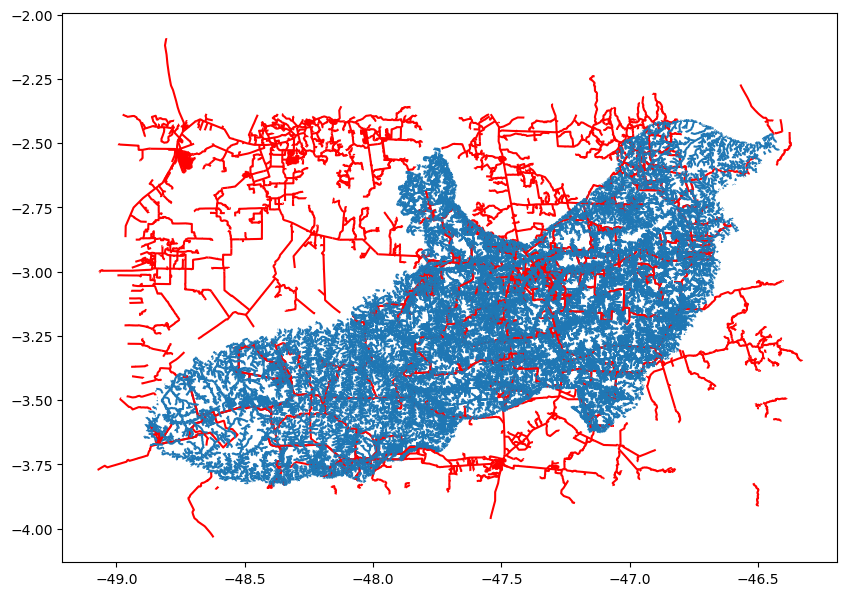

In [9]:
fig, ax = plt.subplots(figsize = (10, 10))
previsia_roads.plot(ax=ax)
osm_roads.plot(ax=ax,
               color = "red")
rivers.plot(ax=ax)

In [10]:
# Find road segments that intersect any river
crossings = gpd.sjoin(osm_roads_f, rivers, predicate="intersects", how="inner")
print(len(crossings), "road segments cross a river")

1629 road segments cross a river


One of the few things we know about the OSM roads is their surface. We will assume that paved roads are safer than unpaved roads, when they cross rivers.

In [11]:
safe_surfaces = ['asphalt', 'paved', 'concrete']
risky_surfaces = ['unpaved', 'gravel', 'dirt', 'ground', 'sand', 'track']
unknown = crossings['surface'].isna()

crossings['risk'] = 'unknown'
crossings.loc[crossings['surface'].isin(safe_surfaces), 'risk'] = 'safe'
crossings.loc[crossings['surface'].isin(risky_surfaces), 'risk'] = 'risky'

In [12]:
# quantify penalty
penalty_map = {'safe': 1, 'unknown': 3, 'risky': 8}

### Apply surface and river penalty to 

In [27]:
# initialize empty graph
G = nx.Graph()

# create nodes
for _, row in osm_roads_f.iterrows(): # loop over every road
    coords = list(row.geometry.coords) # extract line coordinates and save as tuples
    
    # iterate through coords
    for i in range(len(coords) - 1):
        u, v = coords[i], coords[i+1]
        G.add_edge(u, v, weight=haversine(u, v), **row.drop("geometry").to_dict())

safe_surfaces = ['asphalt', 'paved', 'concrete']
risky_surfaces = ['unpaved', 'gravel', 'dirt', 'ground', 'sand', 'track']
unknown = crossings['surface'].isna()

crossings['risk'] = 'unknown'
crossings.loc[crossings['surface'].isin(safe_surfaces), 'risk'] = 'safe'
crossings.loc[crossings['surface'].isin(risky_surfaces), 'risk'] = 'risky'

penalty_map = {'safe': 1, 'unknown': 3, 'risky': 8}

nodes = list(G.nodes())
tree = KDTree(nodes)

def snap(point):
    dist, idx = tree.query(point)
    return nodes[idx], dist

# 1. Get the crossing point geometry for each crossing
crossings['crossing_point'] = crossings.apply(
    lambda row: row.geometry.intersection(rivers.loc[row.index_right].geometry),
    axis=1
)

# 2. Snap each crossing point to the nearest node in G
crossings['nearest_node'] = crossings['crossing_point'].apply(
    lambda pt: snap((pt.x, pt.y))[0] if pt.geom_type == 'Point' else None
)

# 3. Determine risk tier per crossing (from surface, as before)
penalty_map = {'safe': 1, 'unknown': 3, 'risky': 8}
crossings['penalty'] = crossings['risk'].map(penalty_map)

for u, v, data in G.edges(data=True):
    if 'base_weight' not in data:
        data['base_weight'] = data['weight']

for _, row in crossings.dropna(subset=['nearest_node']).iterrows():
    node = row['nearest_node']
    for neighbor in G.neighbors(node):
        G[node][neighbor]['weight'] = G[node][neighbor]['base_weight'] * row['penalty']


results = []
for _, row in test_pairs.iterrows():
    source, source_dist = snap(row.origin)
    target, target_dist = snap(row.dest)
    try:
        path = nx.shortest_path(G, source=source, target=target, weight='weight')
        length = nx.shortest_path_length(G, source=source, target=target, weight='weight')
    except nx.NetworkXNoPath:
        path, length = None, None
    results.append({
        'id': row.id, 'path': path, 'road_distance_m': length,
        'origin_snap_deg': source_dist, 'dest_snap_deg': target_dist
    })

results_df = pd.DataFrame(results)

# convert dest snap to meters
results_df['dest_snap_m'] = results_df['dest_snap_deg'] * 111000

results_df

,id,path,road_distance_m,origin_snap_deg,dest_snap_deg,dest_snap_m
0,par-01,"[(-47.344771, -2.995234), (-47.345218, -2.9947...",47448.240416,0.000214,0.023558,2614.905576
1,par-02,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",82613.807287,0.000214,0.028618,3176.622234
2,par-03,"[(-47.344771, -2.995234), (-47.345218, -2.9947...",62064.103377,0.000214,0.031455,3491.463331
3,par-04,None,NaN,0.000214,0.050589,5615.349448
4,par-05,None,NaN,0.000214,0.050630,5619.894718
5,par-06,"[(-47.344771, -2.995234), (-47.345218, -2.9947...",152905.611188,0.000214,0.022733,2523.345568
6,par-07,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",85485.530206,0.000214,0.028818,3198.852427
7,par-08,None,NaN,0.000214,0.054815,6084.453462
8,par-09,None,NaN,0.000214,0.055747,6187.959412
9,par-10,None,NaN,0.000214,0.050668,5624.107730


In [17]:
penalized_nodes = set(crossings.dropna(subset=['nearest_node'])['nearest_node'])

for _, row in results_df.iterrows():
    if row['path']:
        overlap = [n for n in row['path'] if n in penalized_nodes]
        if overlap:
            print(row['id'], overlap)

par-01 [(-47.344771, -2.995234), (-47.349567, -2.994565), (-47.366174, -2.991966), (-47.381945, -2.990466), (-47.413007, -2.988447), (-47.460056, -2.984395), (-47.464, -2.984043), (-47.479779, -2.982578), (-47.483141, -2.982315), (-47.488382, -2.981844), (-47.492511, -2.981512), (-47.54834, -2.976722), (-47.554501, -2.97618), (-47.559426, -2.975726), (-47.590536, -2.973027), (-47.611929, -2.971091), (-47.622291, -2.969388), (-47.655977, -2.967218), (-47.697624, -2.902444)]
par-02 [(-47.344771, -2.995234), (-47.341575, -2.999718), (-47.338652, -3.008712), (-47.334572, -3.013365), (-47.332254, -3.01619), (-47.314234, -3.089568), (-47.314596, -3.092935), (-47.315886, -3.104414), (-47.317718, -3.121619), (-47.317134, -3.124136), (-47.303596, -3.169609), (-47.302639, -3.172967), (-47.301174, -3.177796), (-47.289359, -3.222246), (-47.267077, -3.307914), (-47.266365, -3.310476), (-47.266145, -3.311375), (-47.263495, -3.321722), (-47.262567, -3.325305), (-47.259804, -3.335643), (-47.256293, -3

In [30]:
row = test_pairs[test_pairs.id == 'par-01'].iloc[0]
source, source_dist = snap(row.origin)
target, target_dist = snap(row.dest)
fresh_length = nx.shortest_path_length(G, source=source, target=target, weight='weight')
print(fresh_length)
print(results_df[results_df.id == 'par-01']['road_distance_m'])

47448.24041582899
0    47448.240416
Name: road_distance_m, dtype: float64


In [35]:
row = test_pairs[test_pairs.id == 'par-01'].iloc[0]
source, source_dist = snap(row.origin)
target, target_dist = snap(row.dest)

path = nx.shortest_path(G, source=source, target=target, weight='weight')
node = (-47.093683, -3.467055)
idx = path.index(node)
print(path[idx-1], node, path[idx+1])

ValueError: (-47.093683, -3.467055) is not in list

In [ ]:
print(type(crossings), type(crossings[0]))
print(type(list(G.nodes())[0]), type(list(G.nodes())[0][0]))

NameError: name 'sample_node' is not defined

In [18]:
sample_node = overlap[0]  # or paste the actual tuple printed above
neighbor = list(G.neighbors(sample_node))[0]
print(G[sample_node][neighbor]['weight'], G[sample_node][neighbor]['base_weight'])

140.976033419811 46.992011139937


In [21]:
path = results_df[results_df.id == 'par-15']['path'].iloc[0]  # the id from your overlap check
idx = path.index(sample_node)
print(path[idx-1] if idx > 0 else None, sample_node, path[idx+1] if idx < len(path)-1 else None)

(-47.094271, -3.467073) (-47.093683, -3.467055) (-47.09326, -3.467037)


In [22]:
print(G[(-47.093683, -3.467055)][(-47.094271, -3.467073)]['weight'],
      G[(-47.093683, -3.467055)][(-47.094271, -3.467073)]['base_weight'])

print(G[(-47.093683, -3.467055)][(-47.09326, -3.467037)]['weight'],
      G[(-47.093683, -3.467055)][(-47.09326, -3.467037)]['base_weight'])

195.8808993294025 65.29363310980084
140.976033419811 46.992011139937


In [15]:
results = []
for _, row in test_pairs.iterrows():
    source, source_dist = snap(row.origin)
    target, target_dist = snap(row.dest)
    try:
        path = nx.shortest_path(G, source=source, target=target, weight='weight')
        length = nx.shortest_path_length(G, source=source, target=target, weight='weight')
    except nx.NetworkXNoPath:
        path, length = None, None
    results.append({
        'id': row.id, 'path': path, 'road_distance_m': length,
        'origin_snap_deg': source_dist, 'dest_snap_deg': target_dist
    })

results_df = pd.DataFrame(results)

# convert dest snap to meters
results_df['dest_snap_m'] = results_df['dest_snap_deg'] * 111000

results_df

,id,path,road_distance_m,origin_snap_deg,dest_snap_deg,dest_snap_m
0,par-01,"[(-47.344771, -2.995234), (-47.345218, -2.9947...",47448.240416,0.000214,0.023558,2614.905576
1,par-02,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",82613.807287,0.000214,0.028618,3176.622234
2,par-03,"[(-47.344771, -2.995234), (-47.345218, -2.9947...",62064.103377,0.000214,0.031455,3491.463331
3,par-04,None,NaN,0.000214,0.050589,5615.349448
4,par-05,None,NaN,0.000214,0.050630,5619.894718
5,par-06,"[(-47.344771, -2.995234), (-47.345218, -2.9947...",152905.611188,0.000214,0.022733,2523.345568
6,par-07,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",85485.530206,0.000214,0.028818,3198.852427
7,par-08,None,NaN,0.000214,0.054815,6084.453462
8,par-09,None,NaN,0.000214,0.055747,6187.959412
9,par-10,None,NaN,0.000214,0.050668,5624.107730


In [16]:
print(len(crossings))
print(crossings['nearest_node'].notna().sum())

1629
1597


In [17]:
print(crossings['crossing_point'].geom_type.value_counts())

Point         1597
MultiPoint      32
Name: count, dtype: int64


In [15]:
penalized_nodes = set(crossings.dropna(subset=['nearest_node'])['nearest_node'])
for _, row in results_df.iterrows():
    if row['path'] and any(n in penalized_nodes for n in row['path']):
        print(row['id'], "crosses a penalized node")

par-01 crosses a penalized node
par-02 crosses a penalized node
par-03 crosses a penalized node
par-06 crosses a penalized node
par-07 crosses a penalized node
par-12 crosses a penalized node
par-15 crosses a penalized node


In [36]:
# --- BASELINE: no penalties ---
G_base = nx.Graph()
for _, row in osm_roads_f.iterrows():
    coords = list(row.geometry.coords)
    for i in range(len(coords) - 1):
        u, v = coords[i], coords[i+1]
        G_base.add_edge(u, v, weight=haversine(u, v), **row.drop("geometry").to_dict())

nodes_base = list(G_base.nodes())
tree_base = KDTree(nodes_base)
def snap_base(point):
    dist, idx = tree_base.query(point)
    return nodes_base[idx], dist

baseline_results = []
for _, row in test_pairs.iterrows():
    source, _ = snap_base(row.origin)
    target, _ = snap_base(row.dest)
    try:
        length = nx.shortest_path_length(G_base, source=source, target=target, weight='weight')
    except nx.NetworkXNoPath:
        length = None
    baseline_results.append({'id': row.id, 'baseline_distance_m': length})

baseline_df = pd.DataFrame(baseline_results)

# --- PENALIZED: G with river penalties already applied ---
penalized_results = []
for _, row in test_pairs.iterrows():
    source, _ = snap(row.origin)
    target, _ = snap(row.dest)
    try:
        length = nx.shortest_path_length(G, source=source, target=target, weight='weight')
    except nx.NetworkXNoPath:
        length = None
    penalized_results.append({'id': row.id, 'penalized_distance_m': length})

penalized_df = pd.DataFrame(penalized_results)

# --- COMPARE ---
comparison = baseline_df.merge(penalized_df, on='id')
comparison['diff_m'] = comparison['penalized_distance_m'] - comparison['baseline_distance_m']
comparison

,id,baseline_distance_m,penalized_distance_m,diff_m
0,par-01,47046.634780,47448.240416,401.605636
1,par-02,64585.638900,82613.807287,18028.168387
2,par-03,61375.744609,62064.103377,688.358768
3,par-04,NaN,NaN,NaN
4,par-05,NaN,NaN,NaN
5,par-06,110433.783646,152905.611188,42471.827541
6,par-07,66855.786671,85485.530206,18629.743535
7,par-08,NaN,NaN,NaN
8,par-09,NaN,NaN,NaN
9,par-10,NaN,NaN,NaN
